In [19]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [20]:
sent_dem = pd.read_csv('sentiment_democracy.csv')

emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

In [21]:
sent_dem.head()

,Unnamed: 0,country,year,n_tokens,n_matched,pct_matched,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment,country_clean,electoral_democracy,liberal_democracy,participatory_democracy
0,0,Afghanistan,2004,10498,1049,0.099924,0.193518,0.405148,0.052431,0.269781,0.329838,0.121068,0.081030,0.655863,0.485224,Afghanistan,0.235,0.089,0.103
1,1,Albania,2008,13961,1411,0.101067,0.165131,0.404678,0.053863,0.244507,0.280652,0.104181,0.068037,0.666194,0.520198,Albania,0.551,0.447,0.348
2,2,Algeria,2008,10756,1122,0.104314,0.098039,0.449198,0.045455,0.179144,0.322638,0.100713,0.084670,0.736185,0.624777,Algeria,0.329,0.165,0.144
3,3,Angola,2010,26408,2381,0.090162,0.178076,0.364133,0.061739,0.235195,0.271315,0.107518,0.061739,0.650987,0.551449,Angola,0.211,0.098,0.060
4,4,Argentina,1994,13152,1119,0.085082,0.161752,0.365505,0.132261,0.215371,0.349419,0.162645,0.080429,0.608579,0.383378,Argentina,0.834,0.633,0.576


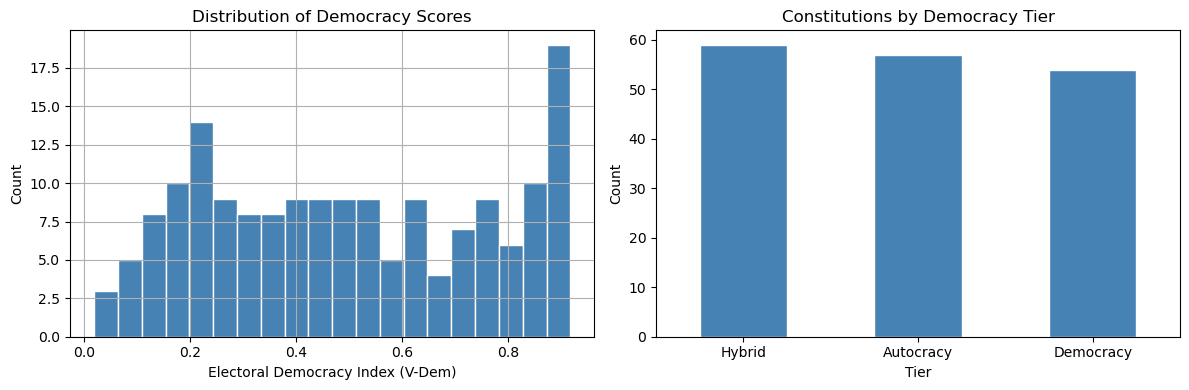

In [22]:

# Distribution of democracy scores in your sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sent_dem['electoral_democracy'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Democracy Scores')
axes[0].set_xlabel('Electoral Democracy Index (V-Dem)')
axes[0].set_ylabel('Count')

# Categorize into democracy tiers for group comparisons
sent_dem['democracy_tier'] = pd.cut(
    sent_dem['electoral_democracy'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Autocracy', 'Hybrid', 'Democracy']
)
sent_dem['democracy_tier'].value_counts().plot(kind='bar', ax=axes[1], 
                                                color='steelblue', edgecolor='white')
axes[1].set_title('Constitutions by Democracy Tier')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

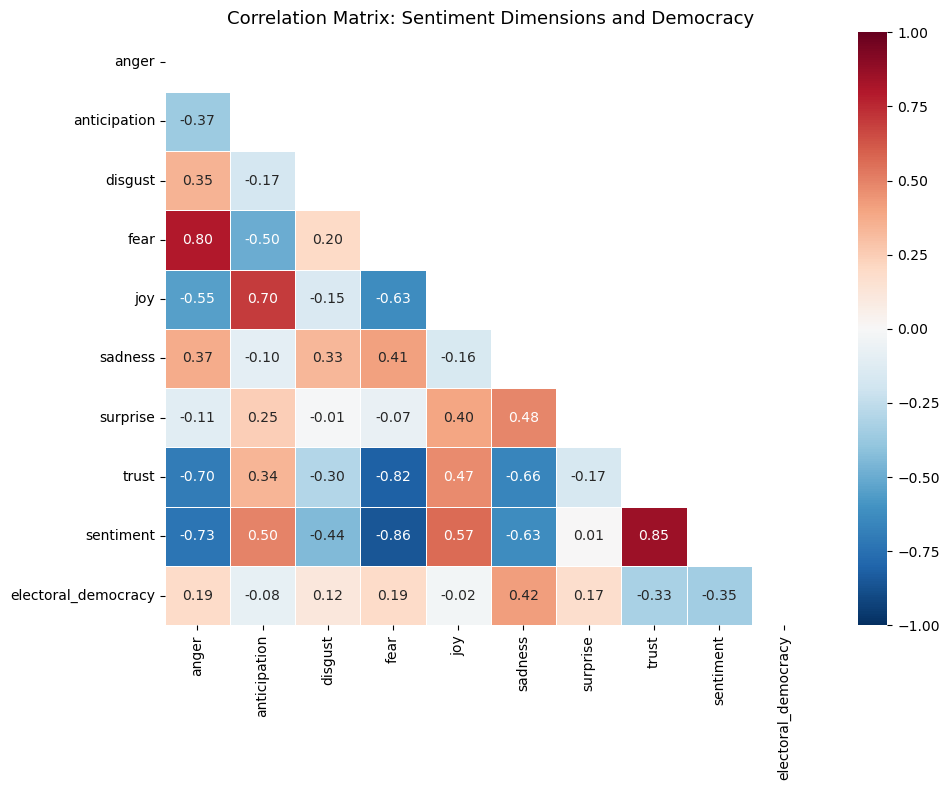

/var/folders/6g/_wpr8bs53rs84lqb6nn_rk900000gn/T/ipykernel_77776/2898240177.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_profiles = sent_dem.groupby('democracy_tier')[emo_cols].mean()


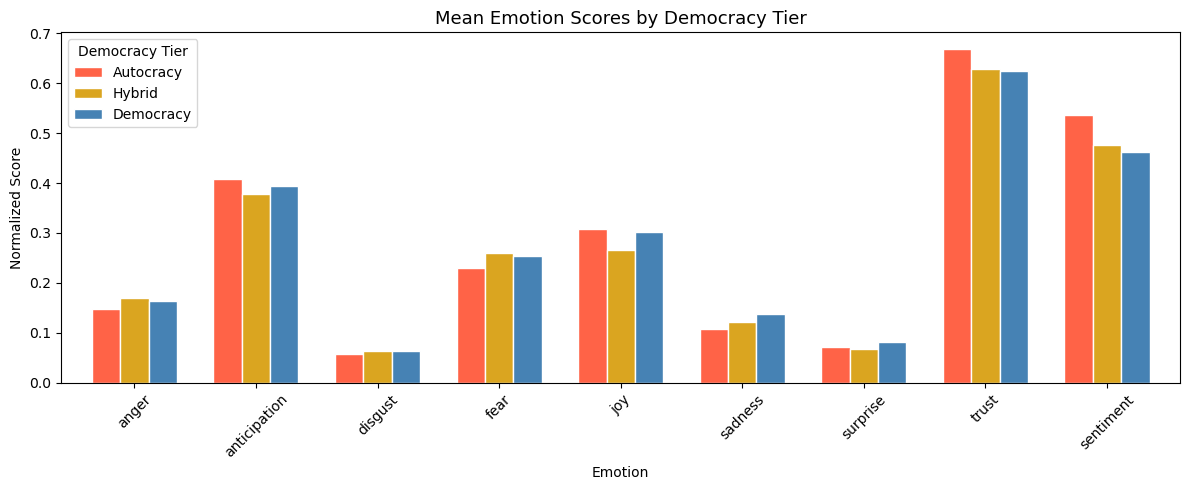

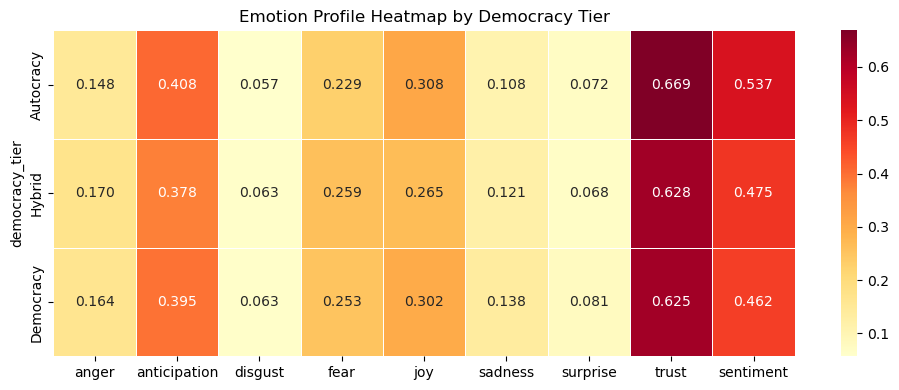

In [33]:
corr_cols = emo_cols + ['electoral_democracy']
CORR_MATRIX = sent_dem[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(CORR_MATRIX, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # hide upper triangle

sns.heatmap(
    CORR_MATRIX,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Matrix: Sentiment Dimensions and Democracy', fontsize=13)
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150)
plt.show()


tier_profiles = sent_dem.groupby('democracy_tier')[emo_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
tier_profiles.T.plot(kind='bar', ax=ax, 
                     color=['tomato', 'goldenrod', 'steelblue'],
                     edgecolor='white', width=0.7)
ax.set_title('Mean Emotion Scores by Democracy Tier', fontsize=13)
ax.set_xlabel('Emotion')
ax.set_ylabel('Normalized Score')
ax.legend(title='Democracy Tier')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('figures/emotion_by_tier.png', dpi=150)
plt.show()

# Also show as a heatmap for cleaner comparison
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    tier_profiles,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Emotion Profile Heatmap by Democracy Tier')
plt.tight_layout()
plt.show()



/var/folders/6g/_wpr8bs53rs84lqb6nn_rk900000gn/T/ipykernel_77776/2702903631.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tier, group in sent_dem.groupby('democracy_tier'):


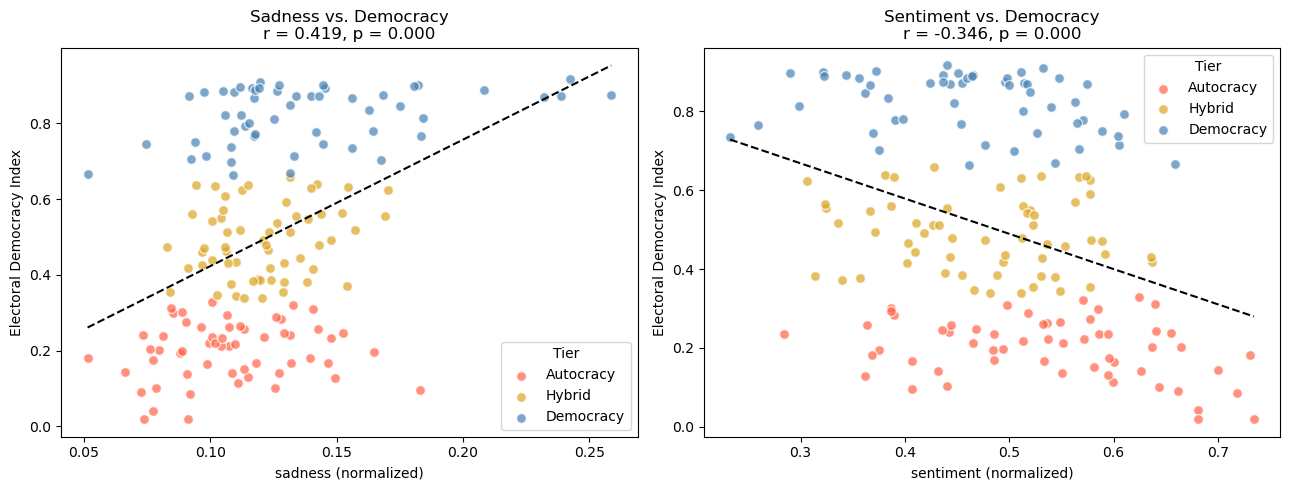

In [26]:

from scipy import stats

# Compute all correlations to find top candidates
correlations = {}
for col in emo_cols:
    r, p = stats.pearsonr(sent_dem[col], sent_dem['electoral_democracy'])
    correlations[col] = {'r': r, 'p': p}

CORR_DF = pd.DataFrame(correlations).T.sort_values('r', ascending=False)
top_pos = CORR_DF[CORR_DF['r'] > 0].index[0]   # strongest positive
top_neg = CORR_DF[CORR_DF['r'] < 0].index[-1]  # strongest negative

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, emotion in zip(axes, [top_pos, top_neg]):
    # Color points by democracy tier
    colors = {'Autocracy': 'tomato', 'Hybrid': 'goldenrod', 'Democracy': 'steelblue'}
    for tier, group in sent_dem.groupby('democracy_tier'):
        ax.scatter(group[emotion], group['electoral_democracy'],
                   label=tier, color=colors[tier],
                   alpha=0.7, s=50, edgecolor='white')

    # Regression line
    m, b = np.polyfit(sent_dem[emotion], sent_dem['electoral_democracy'], 1)
    x_line = np.linspace(sent_dem[emotion].min(), sent_dem[emotion].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

    r, p = stats.pearsonr(sent_dem[emotion], sent_dem['electoral_democracy'])
    ax.set_title(f'{emotion.capitalize()} vs. Democracy\nr = {r:.3f}, p = {p:.3f}')
    ax.set_xlabel(f'{emotion} (normalized)')
    ax.set_ylabel('Electoral Democracy Index')
    ax.legend(title='Tier')

plt.tight_layout()
plt.savefig('figures/top_emotion_scatters.png', dpi=150)
plt.show()



/var/folders/6g/_wpr8bs53rs84lqb6nn_rk900000gn/T/ipykernel_77776/2319903790.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sent_dem, x='region', y='electoral_democracy',


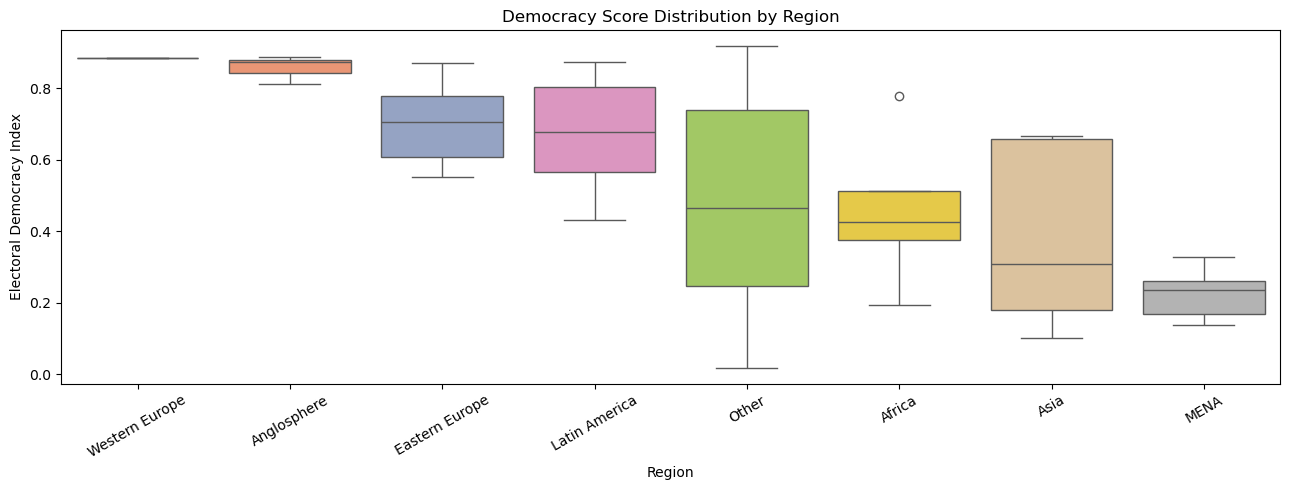

In [27]:
region_map = {
    # Western Europe & Anglosphere
    'Germany': 'Western Europe', 'France': 'Western Europe',
    'United Kingdom': 'Western Europe', 'United States of America': 'Anglosphere',
    'Australia': 'Anglosphere', 'Canada': 'Anglosphere',

    # Eastern Europe
    'Poland': 'Eastern Europe', 'Hungary': 'Eastern Europe',
    'Czechia': 'Eastern Europe', 'Bulgaria': 'Eastern Europe',
    'Romania': 'Eastern Europe', 'Albania': 'Eastern Europe',

    # Latin America
    'Brazil': 'Latin America', 'Mexico': 'Latin America',
    'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'Venezuela': 'Latin America', 'Bolivia': 'Latin America',

    # Africa
    'South Africa': 'Africa', 'Nigeria': 'Africa',
    'Kenya': 'Africa', 'Ghana': 'Africa', 'Ethiopia': 'Africa',

    # Asia
    'China': 'Asia', 'South Korea': 'Asia', 'Japan': 'Asia',
    'India': 'Asia', 'Indonesia': 'Asia', 'Thailand': 'Asia',

    # Middle East & North Africa
    'Iran': 'MENA', 'Egypt': 'MENA', 'Iraq': 'MENA',
    'Algeria': 'MENA', 'Morocco': 'MENA',
}

sent_dem['region'] = sent_dem['country'].map(region_map).fillna('Other')

# Box plot of democracy scores by region
fig, ax = plt.subplots(figsize=(13, 5))
region_order = sent_dem.groupby('region')['electoral_democracy'].median().sort_values(ascending=False).index
sns.boxplot(data=sent_dem, x='region', y='electoral_democracy',
            order=region_order, palette='Set2', ax=ax)
ax.set_title('Democracy Score Distribution by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Electoral Democracy Index')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()



In [28]:


# Standardize both axes for comparison
sent_dem['democracy_z'] = stats.zscore(sent_dem['electoral_democracy'])
sent_dem['sentiment_z'] = stats.zscore(sent_dem['sentiment'])
sent_dem['trust_z'] = stats.zscore(sent_dem['trust'])

# Interesting cases: high democracy, low trust (or vice versa)
sent_dem['residual'] = sent_dem['democracy_z'] - sent_dem['trust_z']

print("=== Most surprising: High democracy, LOW trust language ===")
display(sent_dem.nlargest(5, 'residual')[['country', 'year', 'electoral_democracy', 'trust', 'sentiment']])

print("\n=== Most surprising: Low democracy, HIGH trust language ===")
display(sent_dem.nsmallest(5, 'residual')[['country', 'year', 'electoral_democracy', 'trust', 'sentiment']])



=== Most surprising: High democracy, LOW trust language ===


,country,year,electoral_democracy,trust,sentiment
58,Greece,2008,0.900,0.510529,0.321479
147,Sweden,2012,0.917,0.523772,0.440764
148,Switzerland,2002,0.889,0.527859,0.322581
39,Denmark,1953,0.902,0.531250,0.372396
7,Austria,2009,0.874,0.526622,0.495931



=== Most surprising: Low democracy, HIGH trust language ===


,country,year,electoral_democracy,trust,sentiment
129,Saudi Arabia,2005,0.019,0.798361,0.734426
46,Equatorial Guinea,1995,0.181,0.801105,0.731123
161,United Arab Emirates,2004,0.019,0.757925,0.681076
149,Syria,2012,0.144,0.779176,0.700229
123,Qatar,2003,0.041,0.752809,0.681180


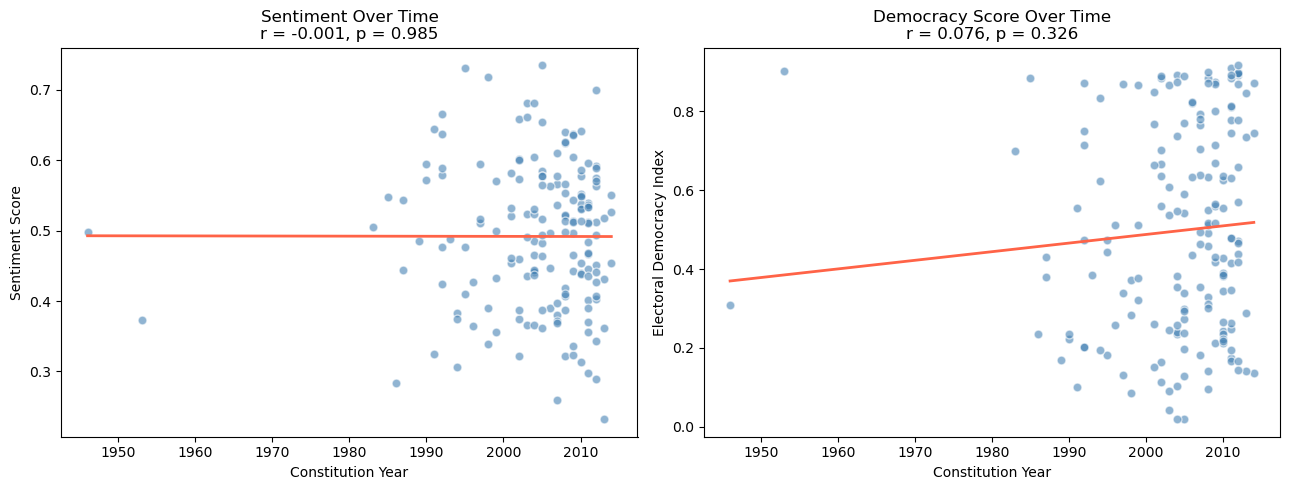

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentiment over time
axes[0].scatter(sent_dem['year'], sent_dem['sentiment'],
                alpha=0.6, color='steelblue', s=40, edgecolor='white')
m, b = np.polyfit(sent_dem['year'], sent_dem['sentiment'], 1)
x_line = np.linspace(sent_dem['year'].min(), sent_dem['year'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='tomato', linewidth=2)
r, p = stats.pearsonr(sent_dem['year'], sent_dem['sentiment'])
axes[0].set_title(f'Sentiment Over Time\nr = {r:.3f}, p = {p:.3f}')
axes[0].set_xlabel('Constitution Year')
axes[0].set_ylabel('Sentiment Score')

# Democracy over time
axes[1].scatter(sent_dem['year'], sent_dem['electoral_democracy'],
                alpha=0.6, color='steelblue', s=40, edgecolor='white')
m, b = np.polyfit(sent_dem['year'], sent_dem['electoral_democracy'], 1)
axes[1].plot(x_line, m * x_line + b, color='tomato', linewidth=2)
r, p = stats.pearsonr(sent_dem['year'], sent_dem['electoral_democracy'])
axes[1].set_title(f'Democracy Score Over Time\nr = {r:.3f}, p = {p:.3f}')
axes[1].set_xlabel('Constitution Year')
axes[1].set_ylabel('Electoral Democracy Index')

plt.tight_layout()
plt.savefig('figures/temporal_patterns.png', dpi=150)
plt.show()



In [32]:
import os
os.mkdir('results')
summary = (
    sent_dem.groupby('democracy_tier')[emo_cols + ['electoral_democracy', 'n_tokens']]
    .agg(['mean', 'std'])
    .round(3)
)

display(summary)
summary.to_csv('results/summary_by_tier.csv')

/var/folders/6g/_wpr8bs53rs84lqb6nn_rk900000gn/T/ipykernel_77776/3977698894.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sent_dem.groupby('democracy_tier')[emo_cols + ['electoral_democracy', 'n_tokens']]


anger        anticipation        disgust          fear         \
                 mean    std         mean    std    mean    std   mean    std   
democracy_tier                                                                  
Autocracy       0.148  0.040        0.408  0.065   0.057  0.025  0.229  0.054   
Hybrid          0.170  0.035        0.378  0.049   0.063  0.022  0.259  0.052   
Democracy       0.164  0.038        0.395  0.064   0.063  0.026  0.253  0.058   

                  joy         ... surprise         trust        sentiment  \
                 mean    std  ...     mean    std   mean    std      mean   
democracy_tier                ...                                           
Autocracy       0.308  0.066  ...    0.072  0.020  0.669  0.064     0.537   
Hybrid          0.265  0.063  ...    0.068  0.017  0.628  0.051     0.475   
Democracy       0.302  0.078  ...    0.081  0.033  0.625  0.066     0.462   

                      electoral_democracy          n_tokens             
                  std                mean    std       mean        std  
democracy_tier                                                          
Autocracy       0.109               0.200  0.076  17051.702  13978.957  
Hybrid          0.086               0.487  0.094  28421.898  18469.586  
Democracy       0.097               0.821  0.075  20772.259  13608.469  

[3 rows x 22 columns]